# <center> Bean Leaf Lesions Classification -「ResNet-18」Bean Leaf Lesions Classification</center>
### <center>If you feel my notebook helpful, support with one upvote, thank you👍</center>

Este notebook se concentra na **classificação de lesões em folhas de feijão** usando a arquitetura de rede neural convolucional ResNet-18. O objetivo é treinar um modelo para distinguir entre folhas saudáveis, com **'angular_leaf_spot'** (mancha angular da folha) e com **'bean_rust'** (ferrugem do feijão).

notebook original: https://www.kaggle.com/code/marquis03/resnet-18-bean-leaf-lesions-classification

# <div style="border-radius:10px; border:#E75480 solid; padding: 15px; background-color: #FFFAF0; font-size:100%; text-align:center">Import Libraries</div>

### Importação de Bibliotecas

Nesta seção, importamos todas as bibliotecas necessárias para o projeto. Isso inclui:

*   `warnings`: Para ignorar mensagens de aviso (útil em notebooks para manter a saída limpa).
*   `lightning` (aka `pytorch_lightning`): Um framework leve para PyTorch que simplifica o treinamento de modelos de deep learning.
*   `random`, `numpy`, `pandas`, `matplotlib.pyplot`, `seaborn`: Para manipulação de dados, visualização e configurações gerais.
*   `torch`, `torchmetrics`, `torch.nn`, `torch.optim`, `torch.nn.functional`, `torch.utils.data`, `torchvision`: Componentes principais do PyTorch para construir, treinar e avaliar redes neurais.

Também configuramos a semente (`seed`) para reprodutibilidade dos resultados em `random`, `numpy`, `torch` e `pytorch_lightning`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install lightning --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 26.7 MB/s eta 0:00:00


In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", font_scale=1.5, font="SimHei", rc={"axes.unicode_minus":False})

import torch
import torchmetrics
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
pl.seed_everything(seed)

INFO: Seed set to 1
INFO:lightning.fabric.utilities.seed:Seed set to 1


1

In [7]:
import kagglehub

dataset_path = kagglehub.dataset_download("marquis03/bean-leaf-lesions-classification")

Using Colab cache for faster access to the 'bean-leaf-lesions-classification' dataset.


### Leitura do Dataset

Este notebook utiliza o dataset "Bean Leaf Lesions Classification" do Kaggle. A célula a seguir faz o download do dataset para o ambiente do Colab usando `kagglehub`. O caminho do dataset baixado é armazenado na variável `dataset_path`.

# <div style="border-radius:10px; border:#E75480 solid; padding: 15px; background-color: #FFFAF0; font-size:100%; text-align:center">Read Dataset</div>

In [8]:
batch_size = 64

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root="/kaggle/input/bean-leaf-lesions-classification/train", transform=train_transform)
val_dataset = datasets.ImageFolder(root="/kaggle/input/bean-leaf-lesions-classification/val", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = val_loader

#### Pré-processamento e Carregamento de Dados

Esta seção define as transformações de imagem para os conjuntos de treinamento e teste, e então carrega as imagens usando `datasets.ImageFolder` e `DataLoader` do PyTorch.

*   `batch_size`: Define o número de imagens processadas por vez, aqui definido como 64.
*   `train_transform`: Define uma sequência de transformações para as imagens de treinamento, incluindo redimensionamento para `(224, 224)` pixels, virada horizontal aleatória (para aumento de dados) e conversão para `ToTensor`.
*   `test_transform`: Define transformações para as imagens de validação/teste, consistindo apenas em redimensionamento e conversão para `ToTensor`.
*   `ImageFolder`: Carrega as imagens de diretórios estruturados (onde cada subpasta é uma classe).
*   `DataLoader`: Cria iteradores para os conjuntos de dados de treinamento, validação e teste, permitindo o carregamento eficiente das imagens em lotes (`batches`) durante o treinamento.

# <div style="border-radius:10px; border:#E75480 solid; padding: 15px; background-color: #FFFAF0; font-size:100%; text-align:center">Visualization</div>

### Visualização

Esta seção do notebook foca na visualização dos dados para entender a distribuição das classes e algumas imagens de exemplo.

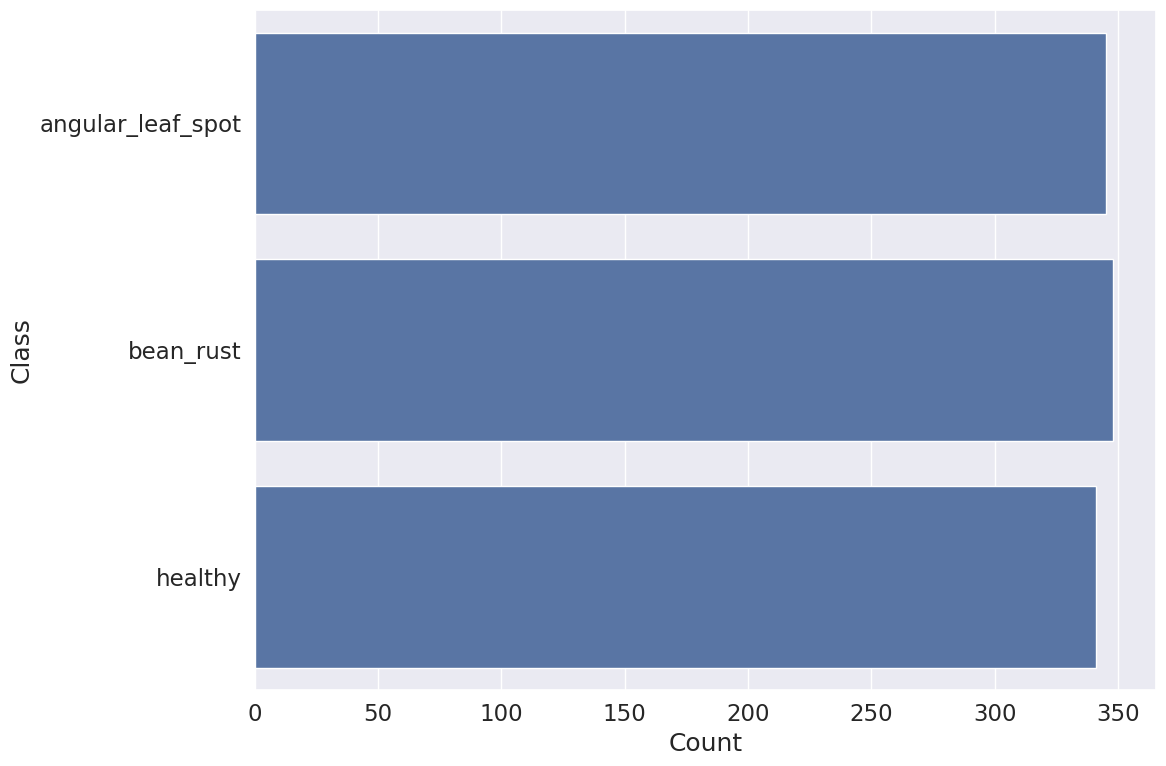

In [11]:
class_names = train_dataset.classes
class_count = [train_dataset.targets.count(i) for i in range(len(class_names))]
df = pd.DataFrame({"Class": class_names, "Count": class_count})

plt.figure(figsize=(12, 8), dpi=100)
sns.barplot(x="Count", y="Class", data=df)
plt.tight_layout()
plt.show()

#### Distribuição das Classes

A primeira visualização mostra a contagem de imagens para cada classe de lesão. Isso é importante para verificar se o dataset está balanceado ou se há alguma classe majoritária/minoritária que possa exigir tratamento especial.

*   `class_names`: Lista com os nomes das classes (ex: 'angular_leaf_spot', 'bean_rust', 'healthy').
*   `class_count`: Lista com o número de imagens em cada classe.
*   Um `DataFrame` do Pandas é criado a partir dessas informações.
*   `sns.barplot`: Gera um gráfico de barras horizontal mostrando a contagem de imagens por classe. O gráfico indica que as três classes estão relativamente balanceadas no conjunto de treinamento.

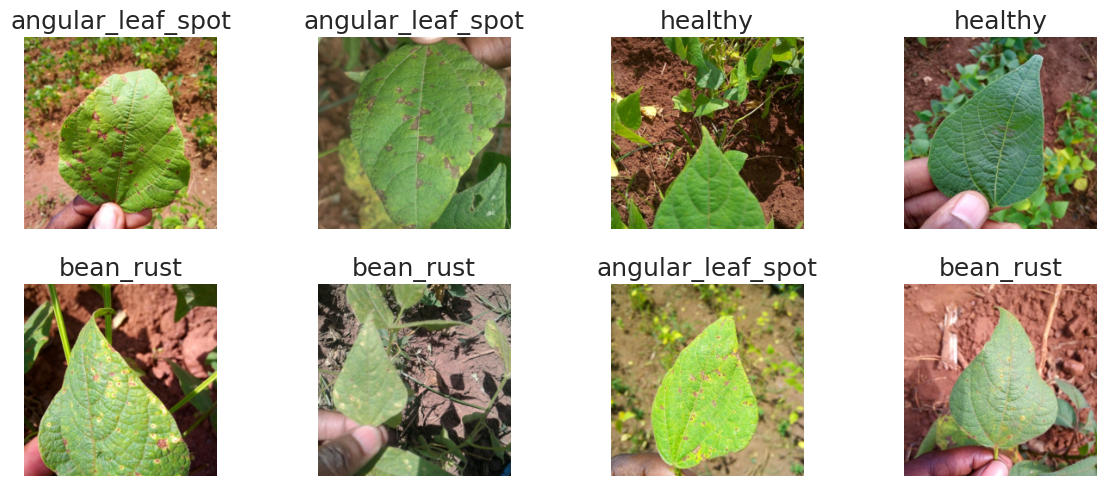

In [10]:
plt.figure(figsize=(12, 20), dpi=100)
images, labels = next(iter(val_loader))
for i in range(8):
    ax = plt.subplot(8, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0).numpy())
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

#### Amostras de Imagens

A segunda visualização exibe uma grade de 8 imagens aleatórias do conjunto de validação, juntamente com seus rótulos de classe. Isso permite uma inspeção visual rápida das imagens que o modelo está tentando classificar.

*   As imagens e os rótulos são obtidos do `val_loader`.
*   `plt.imshow`: Exibe as imagens. `permute(1, 2, 0)` é usado para ajustar as dimensões da imagem de `(C, H, W)` para `(H, W, C)`, que é o formato esperado pelo Matplotlib.
*   Cada imagem é rotulada com seu `class_name` correspondente.

# <div style="border-radius:10px; border:#E75480 solid; padding: 15px; background-color: #FFFAF0; font-size:100%; text-align:center">Modeling</div>

### Modelagem

Esta seção define a arquitetura do modelo usando o framework PyTorch Lightning.

In [13]:
class LitModel(pl.LightningModule):
    def __init__(self, num_classes=1000):
        super().__init__()
        self.model = models.resnet18(weights="IMAGENET1K_V1")
#         for param in self.model.parameters():
#             param.requires_grad = False
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        x = self.model(x)
        return x

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=0.001, betas=(0.9, 0.99), eps=1e-08, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        acc = self.accuracy(y_hat, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        acc = self.accuracy(y_hat, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, logger=True)
        self.log('val_acc', acc, on_step=False, on_epoch=True, prog_bar=True, logger=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        acc = self.accuracy(y_hat, y)
        self.log('test_acc', acc)

    def predict_step(self, batch, batch_idx, dataloader_idx=None):
        x, y = batch
        y_hat = self(x)
        preds = torch.argmax(y_hat, dim=1)
        return preds

#### `LitModel` Class

A classe `LitModel` herda de `pl.LightningModule`, que é a abstração central no PyTorch Lightning para organizar o código do modelo. Isso padroniza o treinamento e facilita a integração com funcionalidades avançadas (como registro de logs, callbacks, etc.).

*   **`__init__`**:
    *   Inicializa o modelo ResNet-18 pré-treinado com `weights="IMAGENET1K_V1"`. O pré-treinamento em ImageNet ajuda o modelo a aprender características visuais genéricas.
    *   A camada final totalmente conectada (`fc`) do ResNet-18 é substituída por uma nova camada `nn.Linear` com `num_classes` saídas, adaptando o modelo para o problema de classificação específico (3 classes de lesões de feijão).
    *   Um objeto `torchmetrics.Accuracy` é inicializado para calcular a acurácia da classificação.
*   **`forward(self, x)`**: Define a passagem para frente (forward pass) dos dados através do modelo. Simplesmente passa a entrada `x` pelo ResNet-18.
*   **`configure_optimizers(self)`**: Define o otimizador a ser usado durante o treinamento. Aqui, é usado o `optim.Adam` com uma taxa de aprendizado (`lr`) de 0.001 e `weight_decay` para regularização.
*   **`training_step(self, batch, batch_idx)`**: Define o que acontece em um único passo de treinamento:
    *   Calcula a saída do modelo (`y_hat`) para um lote (`batch`) de dados.
    *   Calcula a `loss` (perda) usando `F.cross_entropy` (adequado para classificação multiclasse).
    *   Calcula a `acc` (acurácia) para o lote.
    *   Registra a perda e a acurácia de treinamento usando `self.log`.
*   **`validation_step(self, batch, batch_idx)`**: Semelhante ao `training_step`, mas para o conjunto de validação. Calcula a perda e a acurácia de validação.
*   **`test_step(self, batch, batch_idx)`**: Define o passo para o conjunto de teste, calculando e registrando a acurácia de teste.
*   **`predict_step(self, batch, batch_idx, dataloader_idx=None)`**: Define como fazer previsões. Retorna as previsões (índices de classe) para um dado lote.

In [14]:
num_classes = 3
model = LitModel(num_classes=num_classes)
logger = CSVLogger("./")
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=0.00, patience=5, verbose=False, mode="min")
trainer = pl.Trainer(max_epochs=20, enable_progress_bar=True, logger=logger, callbacks=[early_stop_callback])
trainer.fit(model, train_loader, val_loader)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with 

┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.712                                                                     
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

#### Treinamento do Modelo

Esta célula configura e executa o processo de treinamento do modelo.

*   `num_classes`: Definido como 3, correspondendo às três classes de lesões de feijão.
*   `model`: Uma instância da classe `LitModel` é criada.
*   `logger`: Um `CSVLogger` é configurado para registrar métricas de treinamento e validação em um arquivo `metrics.csv` no diretório './'.
*   `early_stop_callback`: Um callback `EarlyStopping` é configurado para monitorar a `val_loss` (perda de validação). Se a perda de validação não melhorar por 5 épocas (`patience=5`), o treinamento será interrompido antecipadamente para evitar overfitting.
*   `trainer`: Uma instância de `pl.Trainer` é criada com:
    *   `max_epochs=20`: O número máximo de épocas para treinar.
    *   `enable_progress_bar=True`: Para exibir uma barra de progresso durante o treinamento.
    *   `logger=logger`: Para usar o logger CSV configurado.
    *   `callbacks=[early_stop_callback]`: Para usar o callback de parada antecipada.
*   `trainer.fit`: Inicia o treinamento do modelo usando os data loaders de treinamento e validação.

In [15]:
trainer.test(model, val_loader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9774436354637146     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.9774436354637146}]

#### Avaliação do Modelo

Após o treinamento, esta célula executa a avaliação final do modelo no conjunto de validação (que está sendo usado como conjunto de teste neste notebook).

*   `trainer.test(model, val_loader)`: Chama o método `test` do `Trainer`, que itera sobre o `val_loader` e executa o `test_step` definido na classe `LitModel` para calcular e reportar a `test_acc` (acurácia de teste). A saída mostra a acurácia final alcançada pelo modelo no conjunto de teste.

# <div style="border-radius:10px; border:#E75480 solid; padding: 15px; background-color: #FFFAF0; font-size:100%; text-align:center">Predict Test Data</div>

### Previsão de Dados de Teste

Esta seção realiza previsões no conjunto de teste e visualiza a distribuição das classes previstas.

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

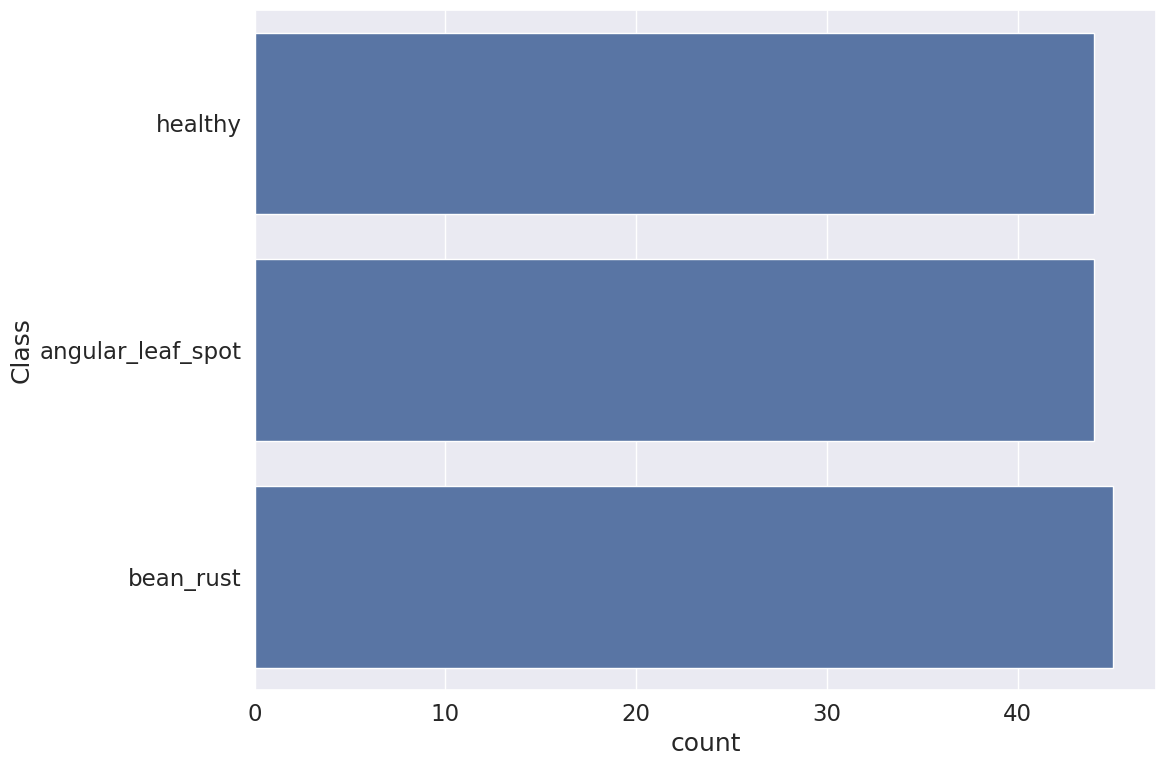

In [16]:
pred = trainer.predict(model, test_loader)
pred = torch.cat(pred, dim=0)
pred = pd.DataFrame(pred.numpy(), columns=["Class"])
pred["Class"] = pred["Class"].apply(lambda x: class_names[x])

plt.figure(figsize=(12, 8), dpi=100)
sns.countplot(y="Class", data=pred)
plt.tight_layout()
plt.show()

#### Gerando e Visualizando Previsões

*   `pred = trainer.predict(model, test_loader)`: O método `predict` do `Trainer` é usado para obter as previsões do modelo no `test_loader`.
*   As previsões (`pred`) são concatenadas, convertidas para um array NumPy e então para um `DataFrame` do Pandas.
*   Os índices de classe numéricos são convertidos de volta para os nomes de classe legíveis por humanos usando `class_names`.
*   `sns.countplot`: Gera um gráfico de barras horizontal mostrando a contagem de cada classe nas previsões. Este gráfico pode ser comparado com a distribuição original das classes (vista na seção de visualização) para entender como o modelo está classificando as amostras do conjunto de teste. Por exemplo, neste caso, o modelo previu um número maior de 'bean_rust' e menor de 'angular_leaf_spot' e 'healthy' em comparação com a distribuição original.

# <div style="border-radius:10px; border:#E75480 solid; padding: 15px; background-color: #FFFAF0; font-size:100%; text-align:center">Loss & Accuracy</div>

### Perda e Acurácia

Esta seção visualiza o progresso do treinamento ao longo das épocas, mostrando como a perda e a acurácia evoluíram para os conjuntos de treinamento e validação.

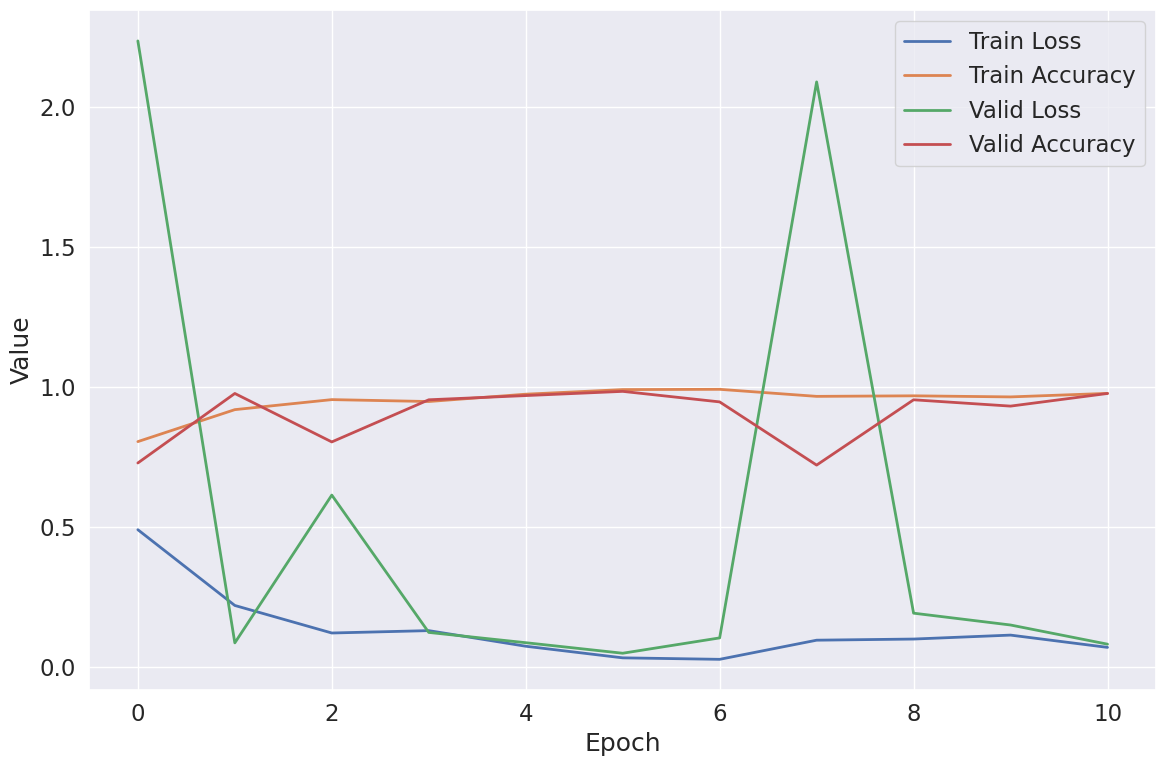

In [17]:
log_path = logger.log_dir + "/metrics.csv"
metrics = pd.read_csv(log_path)

plt.figure(figsize=(12, 8), dpi=100)
sns.lineplot(x="epoch", y="train_loss", data=metrics, label="Train Loss", linewidth=2)
sns.lineplot(x="epoch", y="train_acc", data=metrics, label="Train Accuracy", linewidth=2)
sns.lineplot(x="epoch", y="val_loss", data=metrics, label="Valid Loss", linewidth=2)
sns.lineplot(x="epoch", y="val_acc", data=metrics, label="Valid Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

#### Visualização das Métricas de Treinamento

*   `log_path = logger.log_dir + "/metrics.csv"`: Obtém o caminho para o arquivo CSV onde o `CSVLogger` salvou as métricas de treinamento.
*   `metrics = pd.read_csv(log_path)`: Carrega essas métricas em um `DataFrame` do Pandas.
*   `sns.lineplot`: Gera gráficos de linha para `train_loss`, `train_acc`, `val_loss` e `val_acc` contra `epoch` (época).
    *   **Train Loss (Perda de Treinamento)**: Deve diminuir ao longo do tempo, indicando que o modelo está aprendendo.
    *   **Train Accuracy (Acurácia de Treinamento)**: Deve aumentar ao longo do tempo, indicando que o modelo está melhorando no treinamento.
    *   **Valid Loss (Perda de Validação)**: Deve diminuir e depois possivelmente aumentar se o modelo começar a overfitting.
    *   **Valid Accuracy (Acurácia de Validação)**: Deve aumentar e se estabilizar. Se começar a cair, pode indicar overfitting.

O gráfico resultante mostra o comportamento do modelo durante o treinamento. Podemos observar que a perda de treinamento e validação diminuem nas primeiras épocas, e a acurácia aumenta. Há um ponto onde a perda de validação parece começar a subir novamente (ou ser mais volátil) e a acurácia de validação oscila, o que é um bom indicador para a parada antecipada (`EarlyStopping`) entrar em ação, como configurado anteriormente.